Model Accuracy (Excluding 2020): R² = 0.9166

--- Final Verdict: June 2025 ---
Prediction (No-Covid Trend): 8213.60 MW
Actual Realized Demand:      8440.00 MW
Variance:                    -226.40 MW (-2.7%)

--- Key Driver Weights ---
tempmin: -81.39
humidity: 150.79
feelslike: 77.09
CDD: 612.54
Temp_Sq: 365.87
Heat_Humid_Nexus: -677.64
Year_Index: 629.58


FileNotFoundError: [Errno 2] No such file or directory: 'delhi-weather-aqi-2025.csv'

/tmp/ipython-input-2011904377.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=main_features.sort_values('Coefficient', ascending=False), palette='viridis')



--- June 2025 Prediction ---
Predicted Peak: 7924.16 MW
Actual (Ground Truth): 8440 MW
Error: -515.84 MW


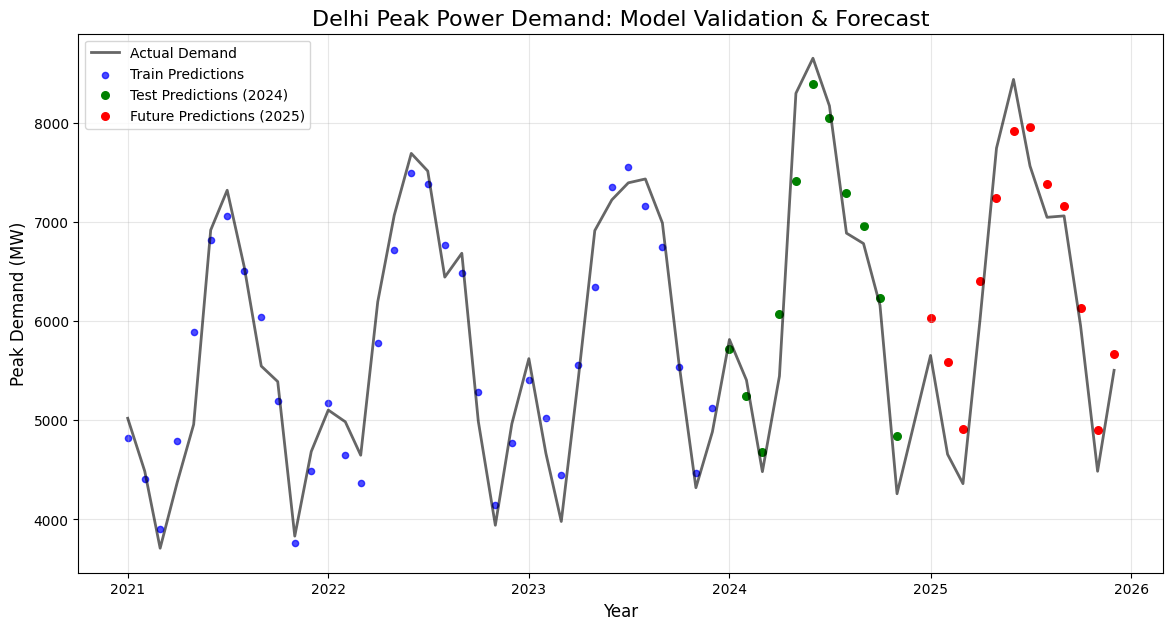

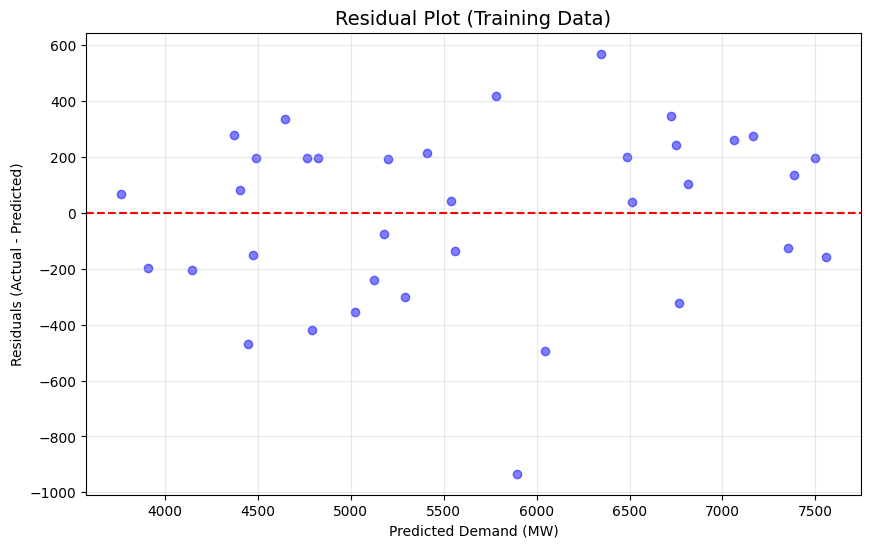

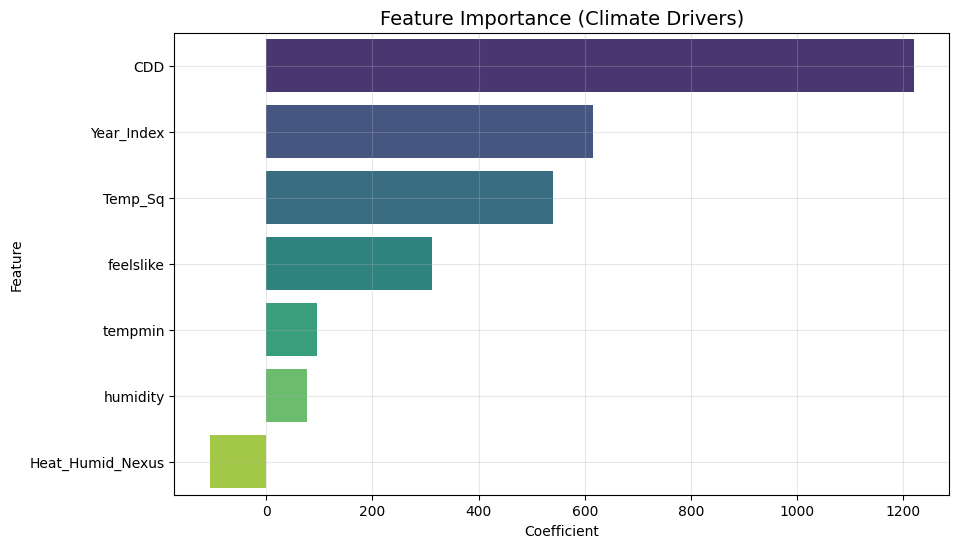

--- OPTIMIZED MODEL METRICS ---
Train R²: 0.9362
Test R² (2024): 0.9195
Test RMSE: 408.40 MW

--- FEATURE IMPORTANCE (Weights) ---
       Feature  Coefficient
0          CDD  1334.946925
6      Month_3  -764.273451
1      Temp_Sq   692.017768
4      Month_1   620.187158
3   Year_Index   617.766326
14    Month_11  -586.427449
10     Month_7   484.018648
9      Month_6   373.499369
7      Month_4  -275.947291
15    Month_12   251.562701


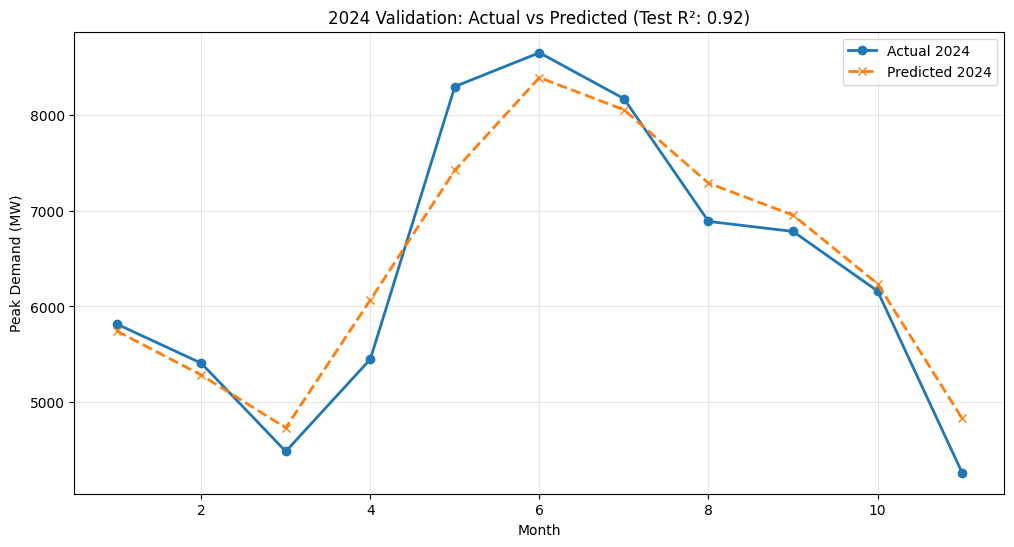

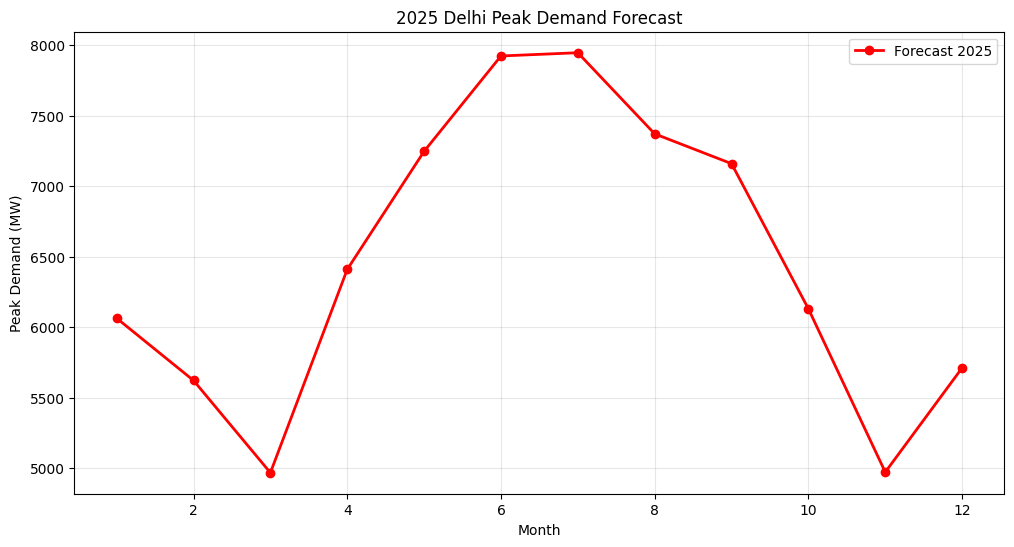

--- OPTIMIZATION RESULT ---
Best Alpha Found: 0.01
Test R² (2024): 0.9439
Test RMSE: 341.05 MW


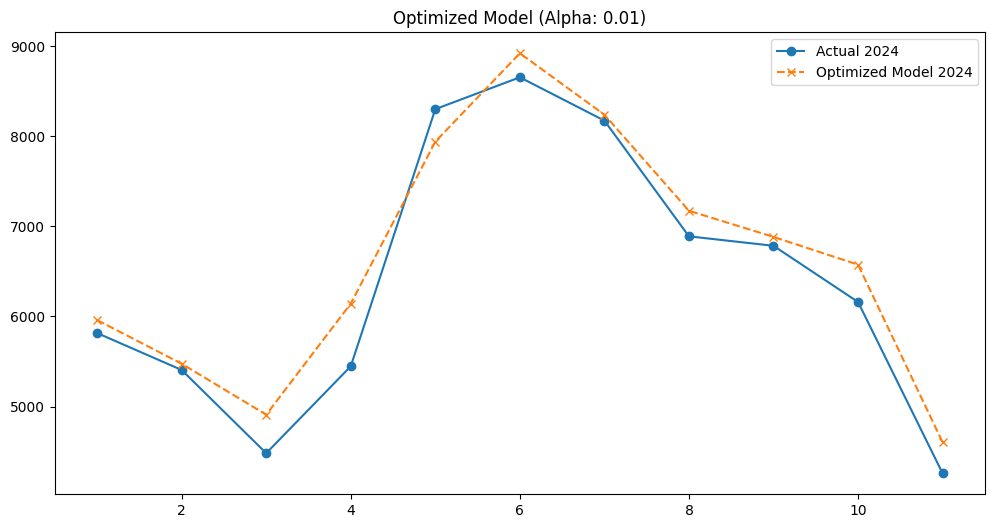


=== FINAL DELHI POWER FORECAST 2025 ===
           Actual_2024  Forecast_2025  Growth_MW  Growth_Percent
Month                                                           
January         5816.0         6318.0      502.0             9.0
February        5406.0         5786.0      380.0             7.0
March           4482.0         5310.0      828.0            18.0
April           5447.0         6593.0     1146.0            21.0
May             8302.0         7325.0     -977.0           -12.0
June            8656.0         7895.0     -761.0            -9.0
July            8175.0         7930.0     -245.0            -3.0
August          6890.0         7182.0      292.0             4.0
September       6785.0         7219.0      434.0             6.0
October         6161.0         6120.0      -41.0            -1.0
November        4259.0         5271.0     1012.0            24.0
December           NaN         5922.0        NaN             NaN


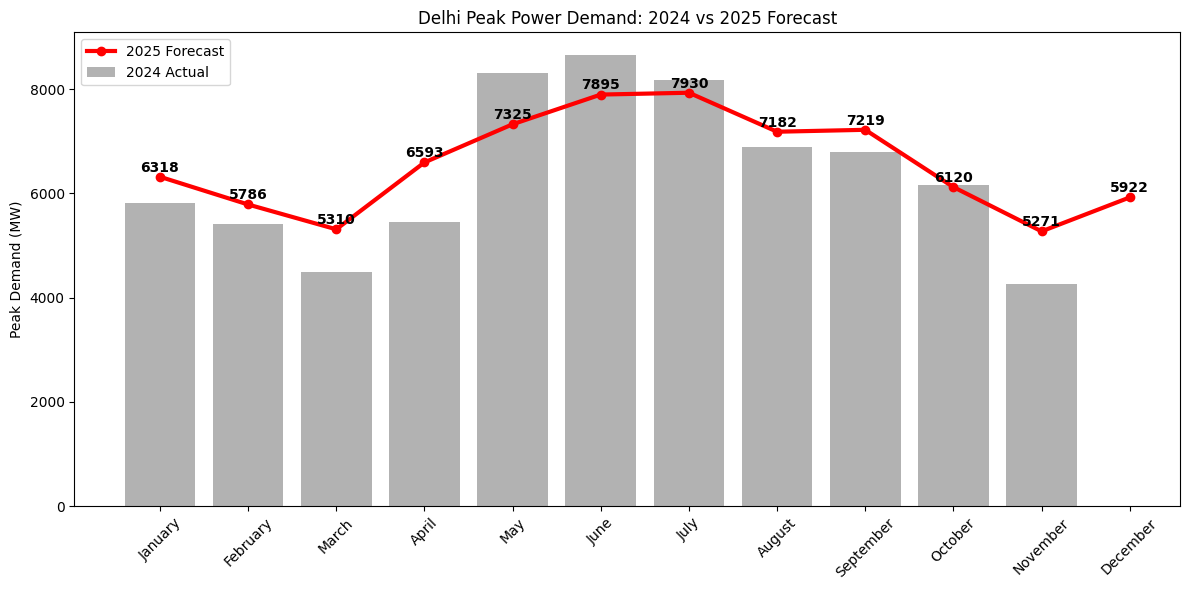

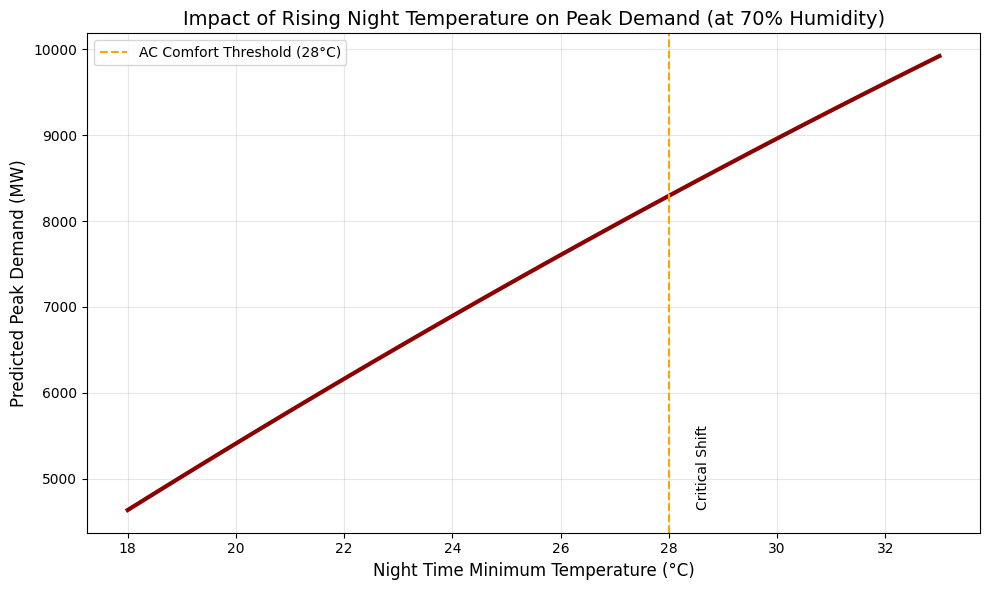


===== MODEL SUMMARY =====
Best Alpha: 0.01
Intercept: 5497.624222503446
Number of predictors: 16

===== TRAIN =====
R²: 0.9606019038593946
Adj R²: 0.92742455974099
RMSE: 240.25612427950685
MAPE: 3.291821137963971

===== TEST (2024) =====
R²: 0.933137095395839
Adj R²: 1.1114381743402684
RMSE: 372.29997143724313
MAPE: 5.75725060390069

Generalization Gap (R²): 0.02746480846355559

===== FULL COEFFICIENT TABLE =====
     Feature  Coefficient  Abs_Coefficient
         CDD  5370.599751      5370.599751
     Temp_Sq -2198.319782      2198.319782
  Year_Index   733.924478       733.924478
    Month_11  -685.166633       685.166633
Heat_x_Humid  -675.425105       675.425105
     Month_3  -663.392172       663.392172
     Month_5  -593.646108       593.646108
     Month_4  -593.155755       593.155755
     Month_8  -478.109810       478.109810
     Month_9  -452.472943       452.472943
     Month_6  -327.350749       327.350749
    Month_12  -286.302170       286.302170
     Month_2  -237.0093

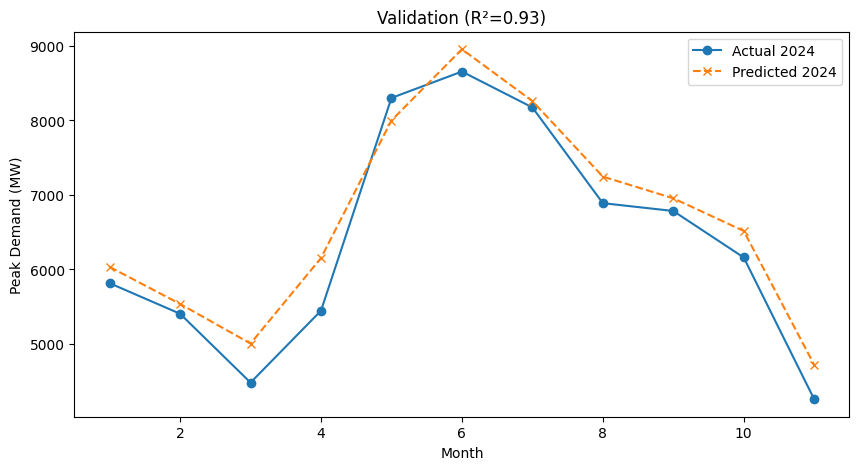

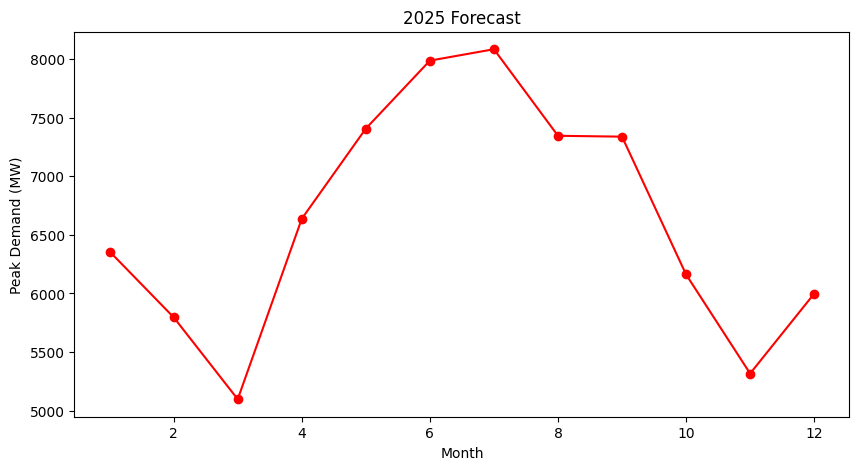

/tmp/ipykernel_27071/968251046.py:234: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_df['Forecast'] = y_future_pred


In [ ]:
# ==========================================
# DELHI PEAK DEMAND FORECAST – RESEARCH MODEL
# RidgeCV + Physics Features + Interaction
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ==========================================
# 1. LOAD DATA
# ==========================================
power = pd.read_csv('power-supply-position-pe.csv')
weather_hist = pd.read_csv('kaggel_weather_2013_to_2024.csv')
weather_2025 = pd.read_csv('delhi-weather-aqi-2025.csv')

# ==========================================
# 2. PHYSICS FUNCTION
# ==========================================
def calc_cdd(t):
    return max(0, t - 18)

# ==========================================
# 3. HISTORICAL WEATHER PROCESSING
# ==========================================
weather_hist['date_obj'] = pd.to_datetime(weather_hist['DATE'], format='mixed')
weather_hist['Year'] = weather_hist['date_obj'].dt.year
weather_hist['Month'] = weather_hist['date_obj'].dt.month

weather_hist['CDD'] = weather_hist['tempmin'].apply(calc_cdd)

hist_monthly = weather_hist.groupby(['Year','Month']).agg({
    'tempmin':'mean',
    'humidity':'mean',
    'CDD':'mean'
}).reset_index()

# ==========================================
# 4. 2025 WEATHER
# ==========================================
weather_2025['dt'] = pd.to_datetime(weather_2025['date_ist'], dayfirst=True)

daily_2025 = weather_2025.groupby(weather_2025['dt'].dt.date).agg({
    'temp_c':'min',
    'humidity':'mean'
})

daily_2025.columns = ['tempmin','humidity']
daily_2025['CDD'] = daily_2025['tempmin'].apply(calc_cdd)

daily_dates = pd.to_datetime(daily_2025.index)
daily_2025['Year'] = daily_dates.year
daily_2025['Month'] = daily_dates.month

future_monthly = daily_2025.groupby(['Year','Month']).agg({
    'tempmin':'mean',
    'humidity':'mean',
    'CDD':'mean'
}).reset_index()

# ==========================================
# 5. POWER DATA
# ==========================================
power_delhi = power[power['Category'].str.contains('Delhi')].copy()
p_dates = pd.to_datetime(power_delhi['Category'].str.split('<br>').str[-1], format='%b-%Y')
power_delhi['Year'] = p_dates.dt.year
power_delhi['Month'] = p_dates.dt.month

power_clean = power_delhi.groupby(['Year','Month'])['Peak Demand'].mean().reset_index()

# ==========================================
# 6. MERGE
# ==========================================
all_weather = pd.concat([hist_monthly, future_monthly], ignore_index=True)

full_data = pd.merge(power_clean, all_weather, on=['Year','Month'])
full_data = full_data.sort_values(['Year','Month'])

# ==========================================
# 7. FEATURE ENGINEERING (FINAL)
# ==========================================

# Trend
full_data['Year_Index'] = full_data['Year'] - 2013

# Non-linear heat
full_data['Temp_Sq'] = full_data['tempmin']**2

# Interaction (KEY research feature)
full_data['Heat_x_Humid'] = full_data['CDD'] * full_data['humidity']

# Month seasonality (drop_first avoids multicollinearity)
month_dummies = pd.get_dummies(full_data['Month'], prefix='Month', drop_first=True)
full_data = pd.concat([full_data, month_dummies], axis=1)

# Final predictors
features = [
    'CDD',
    'Temp_Sq',
    'humidity',
    'Heat_x_Humid',
    'Year_Index'
]

all_predictors = features + list(month_dummies.columns)

# ==========================================
# 8. TRAIN / TEST SPLIT
# ==========================================
train_df = full_data[(full_data['Year'] <= 2023) & (full_data['Year'] != 2020)]
test_df = full_data[full_data['Year'] == 2024]
future_df = full_data[full_data['Year'] == 2025]

X_train = train_df[all_predictors]
y_train = train_df['Peak Demand']

X_test = test_df[all_predictors]
y_test = test_df['Peak Demand']

X_future = future_df[all_predictors]

# ==========================================
# 9. SCALING
# ==========================================
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_future_scaled = scaler.transform(X_future)

# ==========================================
# 10. RIDGECV (AUTO ALPHA)
# ==========================================
alphas = [0.01, 0.1, 0.5, 1, 5, 10, 20]
model = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
model.fit(X_train_scaled, y_train)

print("\n===== MODEL SUMMARY =====")
print("Best Alpha:", model.alpha_)
print("Intercept:", model.intercept_)
print("Number of predictors:", len(all_predictors))

# ==========================================
# 11. PREDICTIONS
# ==========================================
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_future_pred = model.predict(X_future_scaled)

# ==========================================
# 12. METRICS (Research)
# ==========================================
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mse, rmse, r2, mae, mape

train_mse, train_rmse, train_r2, train_mae, train_mape = metrics(y_train, y_train_pred)
test_mse, test_rmse, test_r2, test_mae, test_mape = metrics(y_test, y_test_pred)

# Adjusted R²
n, p = X_train.shape
adj_r2_train = 1 - (1-train_r2)*(n-1)/(n-p-1)

n_test = X_test.shape[0]
adj_r2_test = 1 - (1-test_r2)*(n_test-1)/(n_test-p-1)

# Generalization
print("\n===== TRAIN =====")
print("R²:", train_r2)
print("Adj R²:", adj_r2_train)
print("RMSE:", train_rmse)
print("MAPE:", train_mape)

print("\n===== TEST (2024) =====")
print("R²:", test_r2)
print("Adj R²:", adj_r2_test)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)

print("\nGeneralization Gap (R²):", train_r2 - test_r2)

# ==========================================
# 13. COEFFICIENTS (Correct)
# ==========================================

# Create full coefficient DataFrame
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Add absolute value for importance ranking
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by magnitude (optional)
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("\n===== FULL COEFFICIENT TABLE =====")
print(coef_df_sorted.to_string(index=False))
print("Intercept")
print( model.intercept_)

# Save full table (for paper appendix)
coef_df_sorted.to_csv("full_ridge_coefficients.csv", index=False)

print("\nSaved: full_ridge_coefficients.csv")


# ==========================================
# 14. PLOTS
# ==========================================
plt.figure(figsize=(10,5))
plt.plot(test_df['Month'], y_test, marker='o', label='Actual 2024')
plt.plot(test_df['Month'], y_test_pred, marker='x', linestyle='--', label='Predicted 2024')
plt.title(f'Validation (R²={test_r2:.2f})')
plt.xlabel("Month")
plt.ylabel("Peak Demand (MW)")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(future_df['Month'], y_future_pred, marker='o', color='red')
plt.title("2025 Forecast")
plt.xlabel("Month")
plt.ylabel("Peak Demand (MW)")
plt.show()

future_df['Forecast'] = y_future_pred
future_df[['Year','Month','Forecast']].to_csv("forecast_2025.csv", index=False)
